# 13.2.1 从初始损伤到级联

## 学习目标与先修知识

按同步阈值规则记录直接损伤和各轮继发失效。

先修：11.1 图与连通性；13.1 有限证据；2.1 离散同步更新（synchronous update）。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

网络初始只坏掉一个节点，后续为什么会连续坏掉？我们必须先给出邻居、阈值和同步时序，才能区分直接损伤与级联。

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

四节点链 0—1—2—3，各节点需要至少一个已失效邻居就失效。第0轮只移除节点0，手算接下来的新增集合。

In [2]:
edges=[[0,1],[1,2],[2,3]]
manual=[[0],[1],[2],[3]]
print('第0轮直接损伤及后三轮继发失效：',manual)

第0轮直接损伤及后三轮继发失效： [[0], [1], [2], [3]]


## 模型假设

无向简单图，节点失效不可逆；阈值是正整数，代表所需的已失效邻居个数。第0轮是外生种子。每轮继发节点只依据上一轮末累计失效集合判断，同一轮新失效不立即传播；这里不模拟真实负载重分配。

## 数学解释与推导

令 $F_t$ 为第 $t$ 轮末累计失效集合，$k_i\ge1$ 为阈值。$D_{t+1}=\{i\notin F_t:\sum_{j\in N(i)}1[j\in F_t]\ge k_i\}$，$F_{t+1}=F_t\cup D_{t+1}$。有限节点且不可逆，至多 $N-|F_0|$ 次非空继发轮后停止。若 $F_0=\varnothing$，正阈值下无继发失效。输出（output）要分开保存 $F_0$ 和每个 $D_t$，否则“直接损伤”会与机制放大的损失混淆。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def threshold_cascade(n, edges, thresholds, seeds):
    """Synchronous failed-neighbor count rule; rounds[0] is direct damage."""
    neighbors = [set() for _ in range(n)]
    for a, b in edges:
        neighbors[a].add(b)
        neighbors[b].add(a)
    failed = set(seeds)
    rounds = [sorted(failed)]
    while True:
        added = [i for i in range(n) if i not in failed
                 and sum(j in failed for j in neighbors[i]) >= thresholds[i]]
        if not added:
            return rounds
        failed.update(added)
        rounds.append(sorted(added))

## 对照实验

对同一条链和同一个种子，只改变阈值1与阈值2，逐轮展示累计失效数。

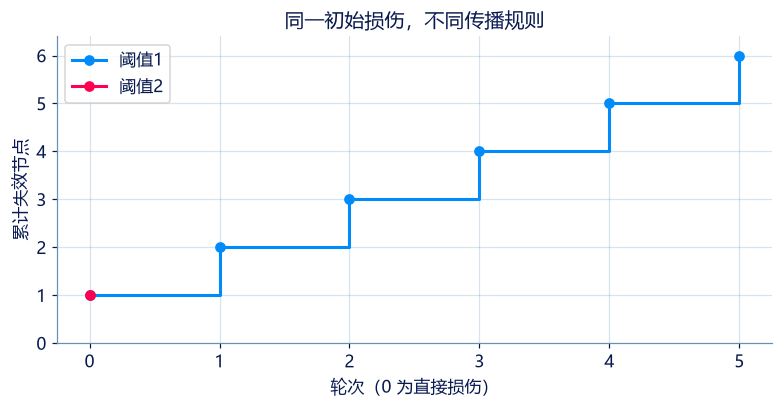

新增集合： {1: [[0], [1], [2], [3], [4], [5]], 2: [[0]]}


In [4]:
n=6;edges=[[i,i+1] for i in range(n-1)]
by_threshold={k:threshold_cascade(n,edges,[k]*n,[0]) for k in [1,2]}
fig,ax=plt.subplots(figsize=(7,3.6))
for k,color in [(1,BLUE),(2,PINK)]:
    rounds=by_threshold[k]
    cumulative=np.cumsum([len(row) for row in rounds])
    ax.step(range(len(cumulative)),cumulative,where='post',marker='o',label=f'阈值{k}',color=color)
ax.set(xlabel='轮次（0 为直接损伤）',ylabel='累计失效节点',ylim=(0,n+.4),title='同一初始损伤，不同传播规则')
ax.legend();ax.grid(alpha=.25);plt.show()
print('新增集合：',by_threshold)

## 结果解释

阈值1沿链逐轮扩散，阈值2在单一端点种子后停止。阈值决定一个节点需要多少失效邻居才会跟着失效，因此改变了传播能否继续。

### 独立核对

用手算六节点链、无种子和高阈值三个边界核验同步集合。

In [5]:
assert by_threshold[1]==[[0],[1],[2],[3],[4],[5]]
assert by_threshold[2]==[[0]]
assert threshold_cascade(3,[[0,1],[1,2]],[1,1,1],[])==[[]]
print('轮次、停止与零种子核对通过。')

轮次、停止与零种子核对通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/13-02-%E7%BA%A7%E8%81%94%E5%A4%B1%E6%95%88%E4%B8%8E%E7%BB%93%E6%9E%84%E9%B2%81%E6%A3%92%E6%80%A7/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：逐轮记录级联失效

给定无向图、各节点至少需要的已失效邻居数 thresholds 与初始损伤 seeds。每轮只读取上一轮末的累计失效状态（state），返回第0轮直接损伤及各轮新失效节点，均升序排列。

**函数与代码模板**

```python
def solve(
    n: int,
    edges: list[list[int]],
    thresholds: list[int],
    seeds: list[int],
) -> list[list[int]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `n` | `int` | 节点数，编号0到n-1。 | 节点 |
| `edges` | `list[list[int]]` | 无向边，每条仅列一次。 | 边 |
| `thresholds` | `list[int]` | 每节点继发失效所需的失效邻居数，均至少1。 | 邻居 |
| `seeds` | `list[int]` | 第0轮直接损伤节点。 | 节点编号 |

**返回值**

直接返回 rounds（list[list[int]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `rounds` | `list[list[int]]` | 第0轮及各轮新增失效节点，不含空终止轮。 | 节点编号 |

**计算规则**

达到阈值的邻居只按已失效节点计数；本轮新增节点不得在本轮继续触发。

**约束与边界**

- 所有比较使用题定模型（model）和相同单位；仅输出（output）函数返回值，不依赖外部文件。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| n | 节点数，编号0到n-1。 | 4 | 节点 |
| edges | 无向边，每条仅列一次。 | [[0, 1], [1, 2], [2, 3]] | 边 |
| thresholds | 每节点继发失效所需的失效邻居数，均至少1。 | [1, 1, 1, 1] | 邻居 |
| seeds | 第0轮直接损伤节点。 | [0] | 节点编号 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
n = 4
edges = [[0, 1], [1, 2], [2, 3]]
thresholds = [1, 1, 1, 1]
seeds = [0]

result = solve(n, edges, thresholds, seeds)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| rounds | 第0轮及各轮新增失效节点，不含空终止轮。 | [[0], [1], [2], [3]] | 节点编号 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[0], [1], [2], [3]]
```

**样例解释**

链上阈值1的种子逐轮传播；阈值2和零种子给出无继发失效的边界。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：逐轮记录级联失效](http://127.0.0.1:8000/chapters/13-02-%E7%BA%A7%E8%81%94%E5%A4%B1%E6%95%88%E4%B8%8E%E7%BB%93%E6%9E%84%E9%B2%81%E6%A3%92%E6%80%A7/practice/?question=p13-cascade-rounds)

### 第 2 题 · 单项选择题：区分直接与继发失效

某链的第0轮 seeds={0}，后续第1轮新增{1}、第2轮新增{2}。哪项是正确记录？

- **A.** 直接损伤1个，继发失效2个，累计失效3个。
- **B.** 直接损伤3个，继发失效0个。
- **C.** 累计失效是1+2+3=6个。
- **D.** 第2轮节点应在第0轮就失效。

[作答：区分直接与继发失效](http://127.0.0.1:8000/chapters/13-02-%E7%BA%A7%E8%81%94%E5%A4%B1%E6%95%88%E4%B8%8E%E7%BB%93%E6%9E%84%E9%B2%81%E6%A3%92%E6%80%A7/practice/?question=p13-direct-vs-secondary)

### 第 3 题 · 单项选择题：零种子的边界

阈值均为至少1个失效邻居，并且没有初始损伤。哪项正确？

- **A.** 不会出现继发失效；返回仅含空第0轮。
- **B.** 全部节点立即失效。
- **C.** 只有度数最高的节点失效。
- **D.** 不能判断，因为网络结构未给出。

[作答：零种子的边界](http://127.0.0.1:8000/chapters/13-02-%E7%BA%A7%E8%81%94%E5%A4%B1%E6%95%88%E4%B8%8E%E7%BB%93%E6%9E%84%E9%B2%81%E6%A3%92%E6%80%A7/practice/?question=p13-cascade-no-seed)

### 第 4 题 · 单项选择题：阈值规则的含义

本章教学网络的节点因“已失效邻居数达到阈值”而失效。它能支持哪项解释？

- **A.** 这是明示的负担或暴露代理规则，不能自动等同于真实疾病传播。
- **B.** 所有网络传播都服从这个阈值。
- **C.** 每个节点在同一轮可反复失效和恢复。
- **D.** 阈值越高，单调增加继发失效。

[作答：阈值规则的含义](http://127.0.0.1:8000/chapters/13-02-%E7%BA%A7%E8%81%94%E5%A4%B1%E6%95%88%E4%B8%8E%E7%BB%93%E6%9E%84%E9%B2%81%E6%A3%92%E6%80%A7/practice/?question=p13-cascade-is-not-contagion)

**进一步阅读**

[Network Science 在线教材](https://networksciencebook.com/translations/en/partials/chapter.html)讨论结构与级联；这里的阈值更新是明示的教学规则。